In [7]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

golden = pd.read_csv("../data/golden_set.csv")
golden = golden.dropna(subset=["intent"])

In [8]:
from sklearn.model_selection import train_test_split

X = golden["text"]
y = golden["intent"]

vectorizer = joblib.load("../results/vectorizer.pkl")
model = joblib.load("../results/intent_model.pkl")

X_vec = vectorizer.transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.5333333333333333
                        precision    recall  f1-score   support

       General Inquiry       0.52      0.93      0.67        14
Login & Account Access       0.00      0.00      0.00         3
       Playback Issues       0.60      0.30      0.40        10
       Premium Billing       0.00      0.00      0.00         3

              accuracy                           0.53        30
             macro avg       0.28      0.31      0.27        30
          weighted avg       0.44      0.53      0.44        30



/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

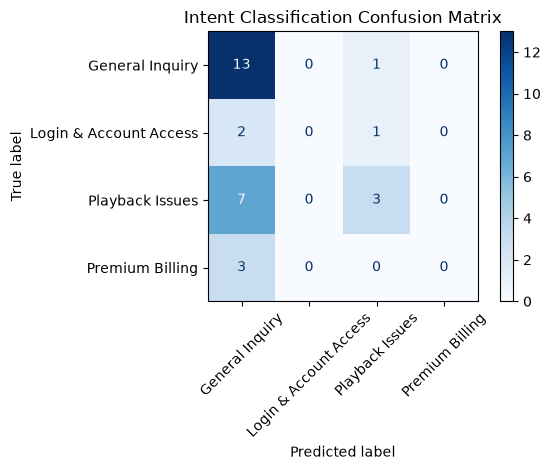

In [10]:

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Intent Classification Confusion Matrix")
plt.tight_layout()

plt.savefig("../results/confusion_matrix.png")
plt.show()